In [1]:
# Set up SAM2 for segmentation

import torch
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import cv2
from sam2.build_sam import build_sam2
from sam2.automatic_mask_generator import SAM2AutomaticMaskGenerator

device = torch.device("mps")

CHECKPOINT = "checkpoints/sam2_hiera_large.pt"
MODEL_CFG = "configs/sam2/sam2_hiera_l.yaml"

sam2_model = build_sam2(MODEL_CFG, CHECKPOINT, device=device)
mask_generator = SAM2AutomaticMaskGenerator(sam2_model, points_per_side=16, points_per_batch=64)
print("SAM2 model loaded!")

SAM2 model loaded!


In [ ]:
def segment(image_path, output_path=None):
    """
    Take in an image, run SAM2, and return best person mask
    """
    # Load image
    image = Image.open(image_path).convert("RGB")
    image_array = np.array(image)

    # Masks for segmentation 
    masks = mask_generator.generate(image_array)

    # Sort by mask area
    masks = sorted(masks, key=lambda m: m['area'], reverse=True)

    # Select mask that most likely matches the human figure
    # (i.e. large area but not the largest [would likely be the entire background])
    area = image_array.shape[0] * image_array.shape[1] # height * width
    silhouette_mask = None

    for mask in masks:
        coverage = mask['area'] / area
        if coverage < 0.70 : # max out at 70% coverage bc don't want background; want biggest area otherwise; masks already sorted by area
            silhouette_mask = mask
            break
    if silhouette_mask is None: # take largest area otherwise 
        silhouette_mask = masks[0]

    # Put mask over image
    silhouette = silhouette_mask['segmentation']
    masked_img = image_array.copy()
    masked_img[~silhouette] = 0  # black out background

    # Plot results
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    axes[0].imshow(image_array)
    axes[0].set_title("Original")
    axes[0].axis('off')

    axes[1].imshow(silhouette, cmap='gray')
    axes[1].set_title("Raw Mask")
    axes[1].axis('off')

    axes[2].imshow(masked_img)
    axes[2].set_title("Human Silhouette")
    axes[2].axis('off')

    plt.tight_layout()
    if output_path:
        plt.savefig(output_path)
    plt.show()

    return silhouette, masked_img

print("Function defined!")

Function defined!


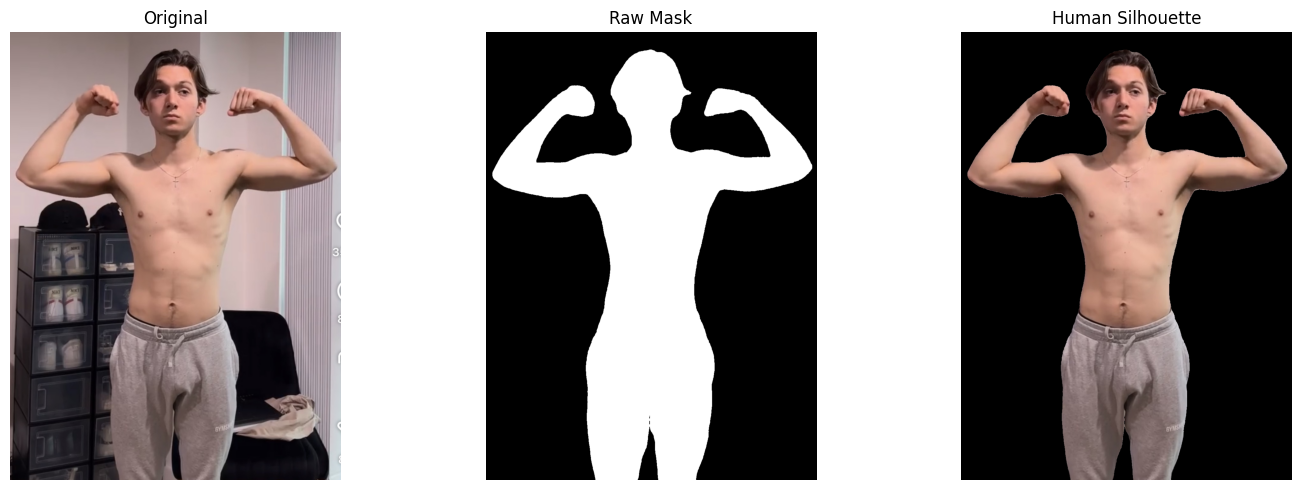

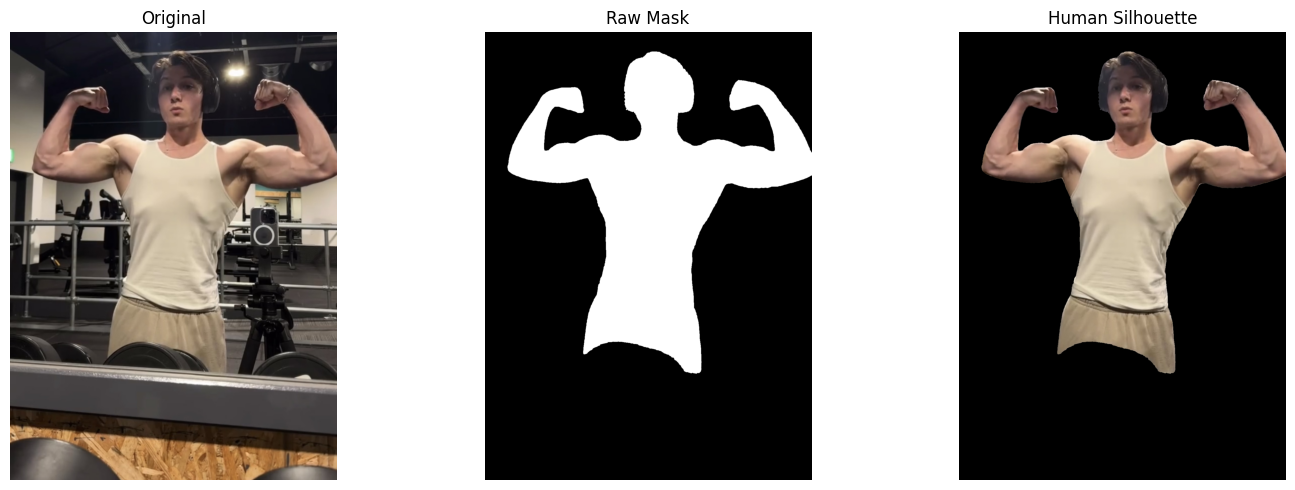

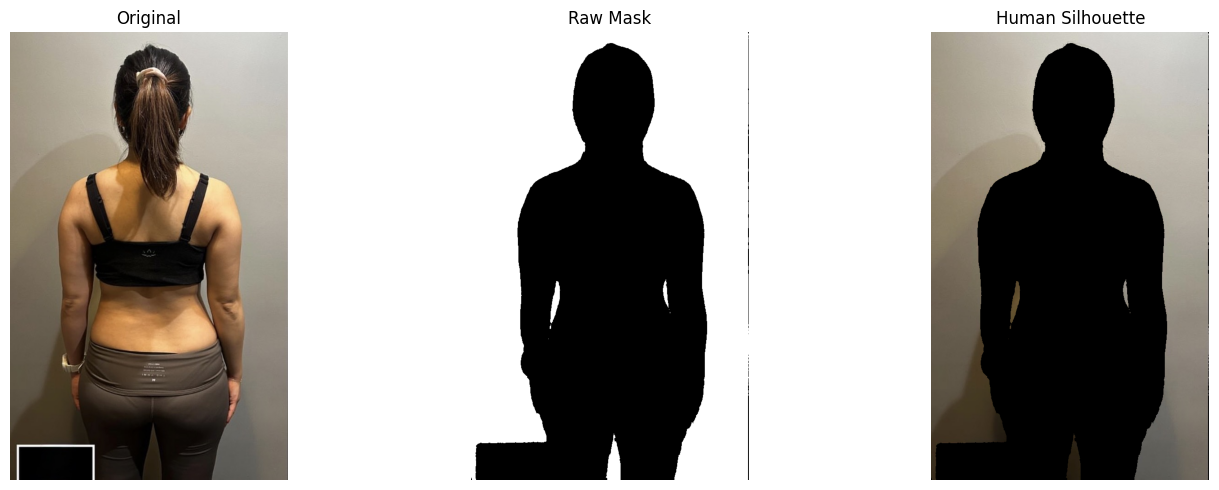

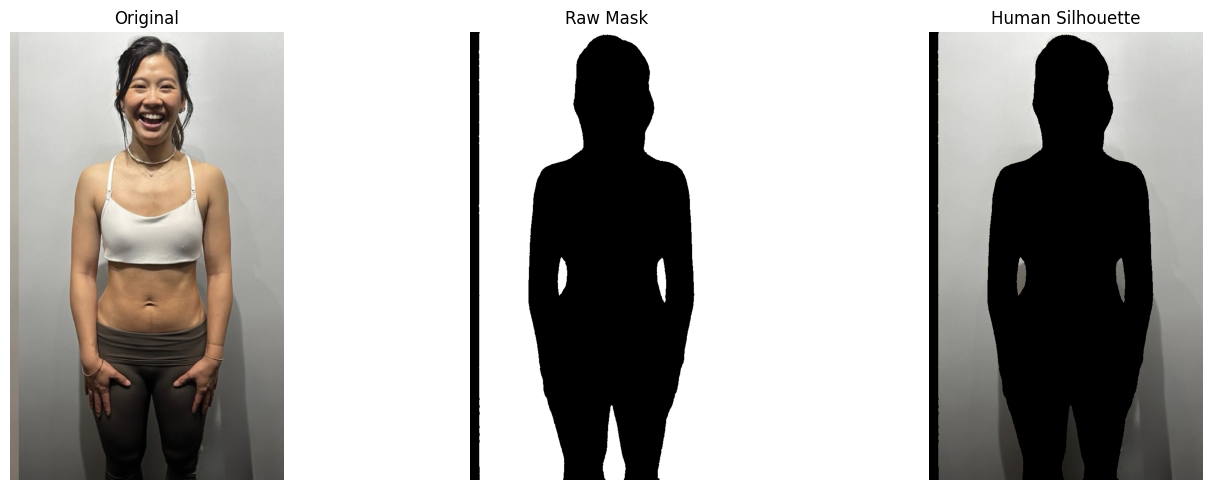

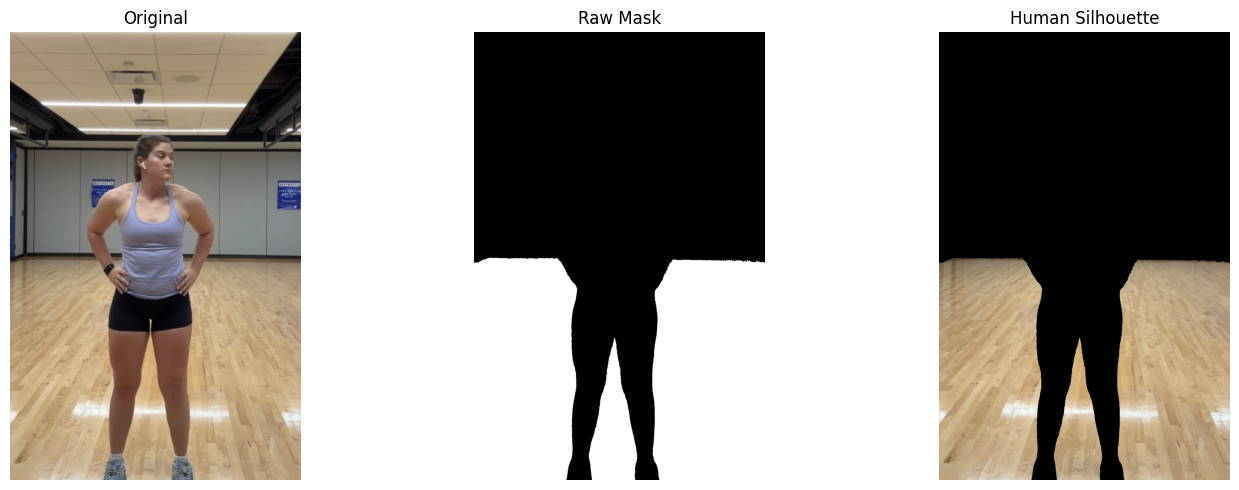

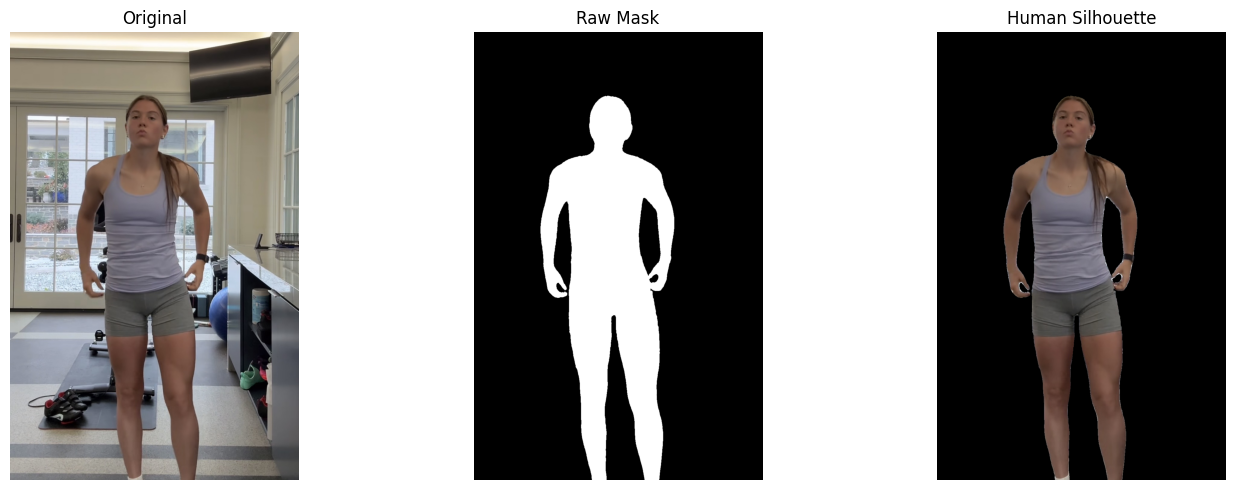

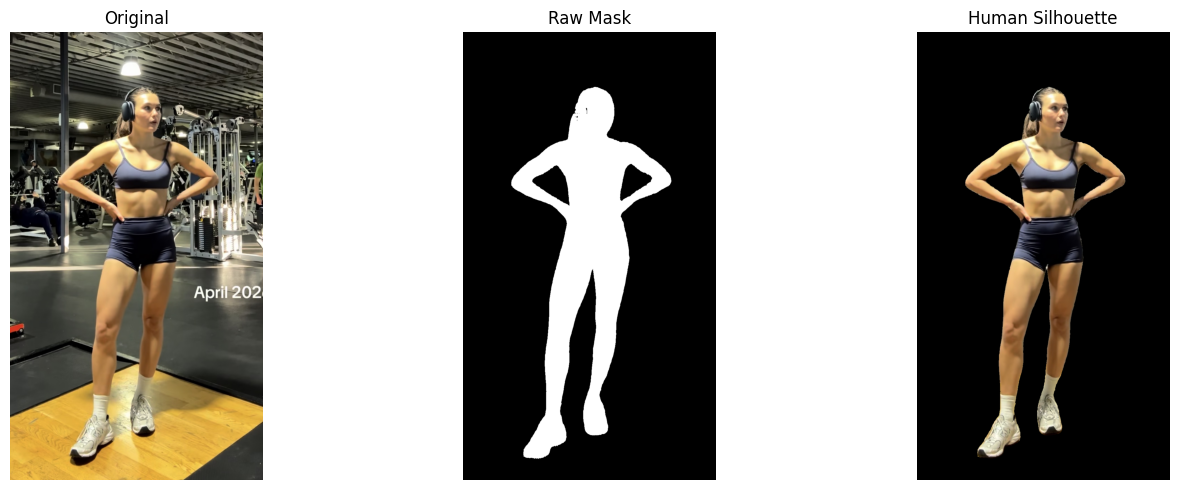

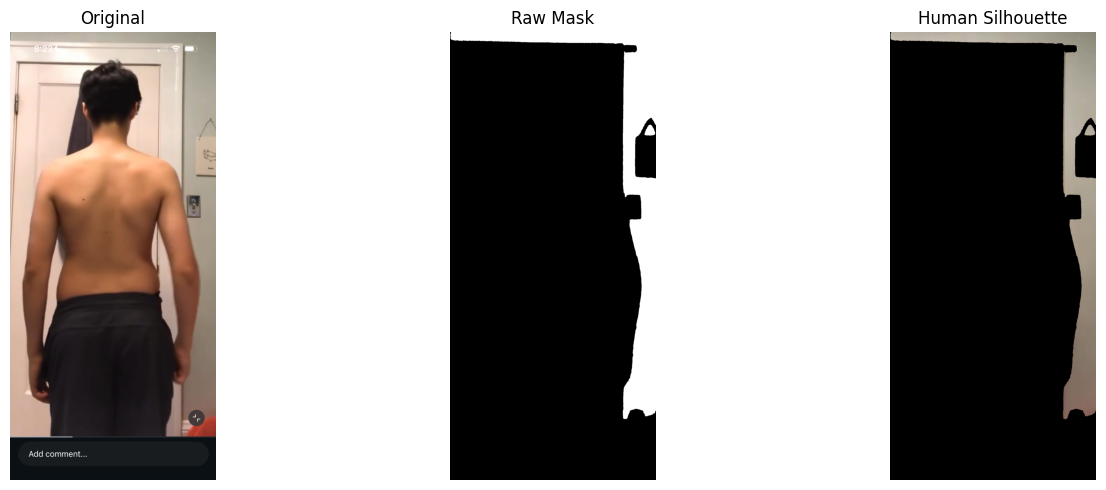

IndexError: list index out of range

In [3]:
# apply segment() to all photos

from pathlib import Path 

# segment("/Users/hannahlatif/Documents/CS131/Final_Project/Milestone/og_photos/dana_a.jpg", "/Users/hannahlatif/Documents/CS131/Final_Project/Milestone/after/dana_a_seg.jpg")

folder_path = Path("/Users/hannahlatif/Documents/CS131/Final_Project/Milestone/og_photos")
for img_path in folder_path.glob("*.jpg"):
    segment(img_path, Path(f"/Users/hannahlatif/Documents/CS131/Final_Project/Milestone/after/{img_path.stem}_segmented{img_path.suffix}"))
